IMPORTS E CONEXÃO AO BANCO

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns


user = 'looqbox-challenge'
password = 'looq-challenge'
host = '35.199.115.174'
port = '3306'
database = 'looqbox-challenge' 

engine = create_engine(f'mysql+pymysql://{user}:{password}@{host}:{port}/{database}')

Resolução dos Casos

In [58]:
#Caso 1
def retrieve_data(product_code=None, store_code=None, date=None):
    
    query = "SELECT * FROM data_product_sales WHERE 1=1"
    
    if product_code is not None:
        query += f" AND PRODUCT_CODE = {product_code}"        
    if store_code is not None:
        query += f" AND STORE_CODE = {store_code}"    
    if date is not None and isinstance(date, list) and len(date) == 2:
        query += f" AND DATE BETWEEN '{date[0]}' AND '{date[1]}'"
        
    df = pd.read_sql(query, engine)
    
    return df

my_data = retrieve_data(product_code=10, date=['2019-01-01', '2019-01-31'])
display(my_data.head())

,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,10,10,2019-01-01,2386.15,65.0
1,10,10,2019-01-02,4368.49,119.0
2,10,10,2019-01-03,3854.55,105.0
3,10,10,2019-01-04,3671.00,100.0
4,10,10,2019-01-05,3010.22,82.0


In [59]:
#Caso 2

query_1 = """
SELECT
      STORE_CODE,
      STORE_NAME,
      START_DATE,
      END_DATE,
      BUSINESS_NAME,
      BUSINESS_CODE
FROM data_store_cad
"""

query_2 = """
SELECT
        STORE_CODE,
        DATE,
        SALES_VALUE,
        SALES_QTY
FROM data_store_sales
WHERE DATE BETWEEN '2019-01-01' AND '2019-12-31'
"""

df_cad = pd.read_sql(query_1, engine)
df_sales = pd.read_sql(query_2, engine)

df_sales['DATE'] = pd.to_datetime(df_sales['DATE'])
data_inicio = '2019-10-01'
data_fim = '2019-12-31'
df_sales_filtrado = df_sales[(df_sales['DATE'] >= data_inicio) & (df_sales['DATE'] <= data_fim)]

df_combinado = pd.merge(df_sales_filtrado, df_cad, on='STORE_CODE', how='inner')

df_agrupado = df_combinado.groupby(['STORE_NAME', 'BUSINESS_NAME']).agg({
    'SALES_VALUE': 'sum',
    'SALES_QTY': 'sum'
}).reset_index()

df_agrupado['TM'] = (df_agrupado['SALES_VALUE'] / df_agrupado['SALES_QTY']).round(2)

df_final = df_agrupado[['STORE_NAME', 'BUSINESS_NAME', 'TM']].copy()
df_final.columns = ['Loja', 'Categoria', 'TM']
df_final = df_final.sort_values(by='Loja').reset_index(drop=True)

display(df_final)

,Loja,Categoria,TM
0,Bahia,Atacado,15.39
1,Bangkok,Posto,13.67
2,Belem,Proximidade,15.37
3,Berlin,Proximidade,15.39
4,Buenos Aires,Atacado,15.39
5,Chicago,Varejo,15.53
6,Dubai,Atacado,15.39
7,Hong Kong,Farma,26.35
8,London,Farma,28.99
9,Madri,Farma,29.03


C:\Users\Pichau\AppData\Local\Temp\ipykernel_6168\873442259.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  eixo1.set_xticklabels(df_top.index, rotation=45, ha='right', fontsize=11, color=cor_texto)


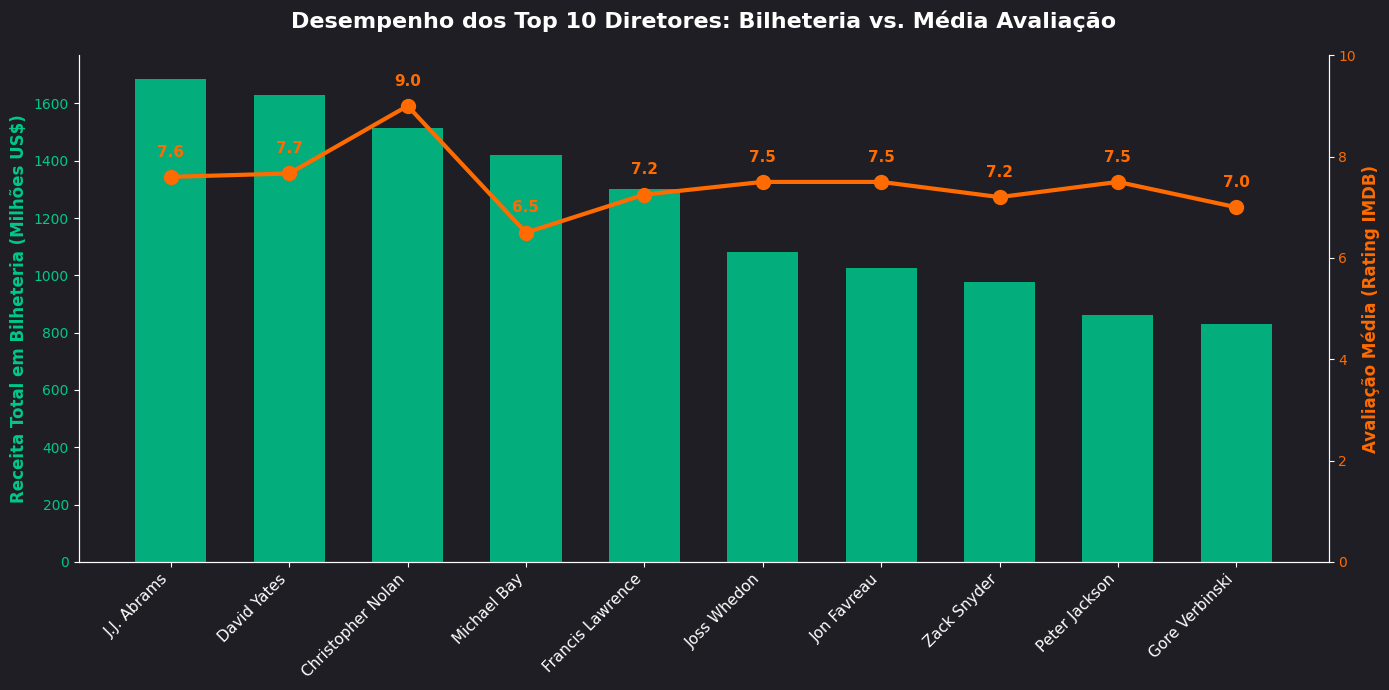

In [ ]:
# Caso 3
query_imdb = "SELECT * FROM IMDB_movies"
df_imdb = pd.read_sql(query_imdb, engine)

df_top = df_imdb.groupby('Director').agg(
    Receita_Total=('RevenueMillions', 'sum'),
    Rating_Medio=('Rating', 'mean')
).sort_values(by='Receita_Total', ascending=False).head(10)

cor_fundo = '#1e1e24'         
cor_barra_verde = '#00C88C'   
cor_linha_laranja = '#FF6B00' 
cor_texto = '#FFFFFF'         

plt.style.use('dark_background')
fig, eixo1 = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(cor_fundo)
eixo1.set_facecolor(cor_fundo)

eixo1.bar(df_top.index, df_top['Receita_Total'], color=cor_barra_verde, alpha=0.85, width=0.6)
eixo1.set_ylabel('Receita Total em Bilheteria', color=cor_barra_verde, fontsize=12, fontweight='bold')
eixo1.tick_params(axis='y', labelcolor=cor_barra_verde)
eixo1.set_xticklabels(df_top.index, rotation=45, ha='right', fontsize=11, color=cor_texto)

eixo2 = eixo1.twinx()
eixo2.plot(df_top.index, df_top['Rating_Medio'], color=cor_linha_laranja, marker='o', linewidth=3, markersize=10)
eixo2.set_ylabel('Avaliação Média', color=cor_linha_laranja, fontsize=12, fontweight='bold')
eixo2.tick_params(axis='y', labelcolor=cor_linha_laranja)
eixo2.set_ylim(0, 10) 

for i, txt in enumerate(df_top['Rating_Medio']):
    eixo2.annotate(f"{txt:.1f}", (i, df_top['Rating_Medio'].iloc[i] + 0.4), ha='center', color=cor_linha_laranja, fontweight='bold', fontsize=11)

plt.title('Desempenho dos Top 10 Diretores: Bilheteria vs. Média Avaliação', color=cor_texto, fontsize=16, pad=20, fontweight='bold')
eixo1.spines['top'].set_visible(False)
eixo2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()